# Steam Games – Data Mining Project
## Section 1: Business Understanding & Data Loading

**Team 9 – Brewed Clusters**

---

### What are we trying to do?

We have data on ~120,000 Steam games and we want to answer three real-world questions:

1. **Will a game be well-received?**  
   → *Classification task* – predict Good (positive) or Bad (negative) reception based on a game's metadata

2. **How many people will play it at the same time at its peak?**  
   → *Regression task* – predict the peak concurrent user count (CCU)

3. **What natural groups of games exist in the market?**  
   → *Clustering task* – discover segments like "cheap indie games", "AAA shooters", etc.

This notebook covers the first step: **loading the raw data and taking an initial look at it**.


---
## Step 0 – Install / Import Libraries

We load all the Python libraries we need here at the top.  
Think of these as the tools we're bringing out before starting work.


In [5]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings to keep output clean

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd    # the main tool for working with tables (DataFrames)
import numpy as np     # math/array operations

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # basic plotting
import seaborn as sns             # nicer-looking statistical plots

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)   # show all columns when printing
pd.set_option('display.max_colwidth', 60)  # don't truncate cell text too early
sns.set_theme(style='whitegrid')           # clean white background for all plots

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Step 1 – Load the Raw Dataset

We read the CSV file from the `Data/` folder.  
CSV stands for *Comma-Separated Values* — basically a spreadsheet saved as plain text.

**`low_memory=False`** tells pandas to read the whole file before deciding what data type  
each column is (otherwise it might guess wrong on large files).


In [6]:
# Path to the raw data file
DATA_PATH = 'Data/games.csv'

# Load the CSV into a pandas DataFrame
# A DataFrame is like an Excel table: rows = games, columns = attributes
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

Dataset loaded: 122,611 rows × 39 columns


---
## Step 2 – First Look at the Data

Before doing anything else, we always **look at the raw data**.  
This helps us understand what information we have and spot obvious issues.


In [7]:
# Show the first 5 rows
# This gives a quick feel for what the data looks like
df_raw.head(5)

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come into full ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sha...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_item_assets/...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical and entra...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Color...",https://shared.akamai.steamstatic.com/store_item_assets/...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' It's been ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. General Mat...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the captivating ...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_item_assets/...,NaN


In [8]:
# List all column names
# These are all the features (attributes) available for each game
print('Columns in the dataset:')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:2d}. {col}')

Columns in the dataset:
   1. AppID
   2. Name
   3. Release date
   4. Estimated owners
   5. Peak CCU
   6. Required age
   7. Price
   8. DiscountDLC count
   9. About the game
  10. Supported languages
  11. Full audio languages
  12. Reviews
  13. Header image
  14. Website
  15. Support url
  16. Support email
  17. Windows
  18. Mac
  19. Linux
  20. Metacritic score
  21. Metacritic url
  22. User score
  23. Positive
  24. Negative
  25. Score rank
  26. Achievements
  27. Recommendations
  28. Notes
  29. Average playtime forever
  30. Average playtime two weeks
  31. Median playtime forever
  32. Median playtime two weeks
  33. Developers
  34. Publishers
  35. Categories
  36. Genres
  37. Tags
  38. Screenshots
  39. Movies


---
## Step 3 – Data Types and Basic Info

`df.info()` is like a summary sheet — it tells us:
- How many entries (rows) we have
- What data type each column is (number, text, boolean True/False, etc.)
- How many non-null (non-empty) values each column has

**Why does data type matter?**  
A column stored as text ("object") can't be used directly in a mathematical model.  
We'll need to convert things like price (stored as text "5.24") to actual numbers.


In [9]:
# Full summary of every column
df_raw.info()

<class 'pandas.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  str    
 1   Name                        122611 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  str    
 9   Supported languages         122611 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     12070 non-null   str    
 12  Header image                122530 non-null  str    
 13  Website                

---
## Step 4 – Missing Values

Missing values (NaN = "Not a Number") are gaps in the data — like a cell left blank in Excel.  
We need to know how many missing values exist before we can decide how to handle them.

**Strategy** (from our project outline):
- Numeric columns with missing values → fill with the **median** (middle value)
- Text columns → fill with an empty string or a placeholder
- Columns that are almost entirely empty → drop them


In [10]:
# Count missing values in each column and show as a percentage of total rows
missing = df_raw.isnull().sum()                        # count of missing values per column
missing_pct = (missing / len(df_raw) * 100).round(2)   # convert to percentage

# Build a readable summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)  # sort worst columns first

# Only show columns that actually have missing data
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

print(f'Columns with missing values: {len(missing_summary)}')
missing_summary

Columns with missing values: 17


,Missing Count,Missing %
Movies,122611,100.00
Score rank,122571,99.97
Metacritic url,118355,96.53
Reviews,110541,90.16
Notes,100153,81.68
Website,72935,59.48
Support url,68469,55.84
Tags,39265,32.02
Support email,22263,18.16
Categories,8953,7.30


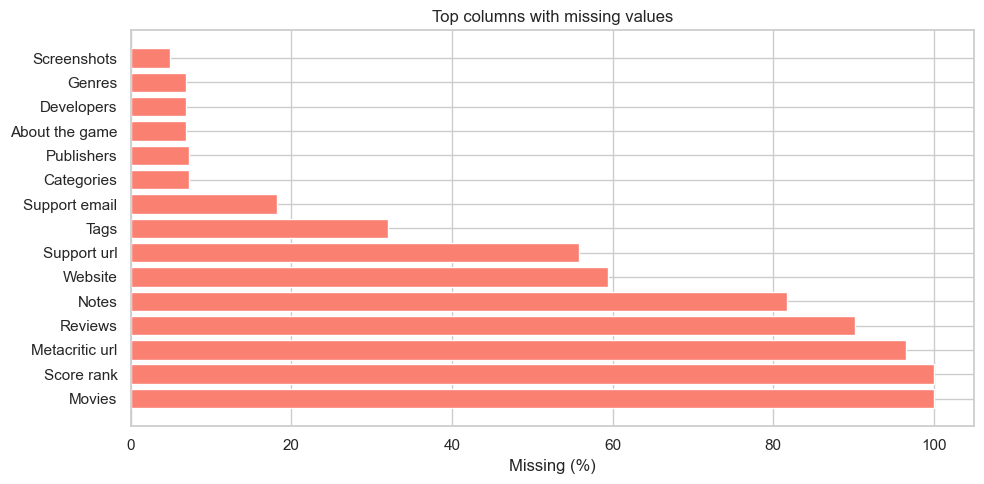

In [11]:
# Visualise: bar chart of columns with the most missing data
top_missing = missing_summary.head(15)  # top 15 worst columns

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_missing.index, top_missing['Missing %'], color='salmon')
ax.set_xlabel('Missing (%)')
ax.set_title('Top columns with missing values')
plt.tight_layout()
plt.show()

---
## Step 5 – Basic Statistics for Numeric Columns

`df.describe()` gives us the **summary statistics** for every numeric column:

| Stat | What it means |
|------|---------------|
| `count` | How many non-missing values |
| `mean` | Average |
| `std` | Standard deviation — how spread out the values are |
| `min` / `max` | Smallest and largest values |
| `25% / 50% / 75%` | Percentiles — 50% is the median |

This helps us spot **outliers** — for example, if the maximum Peak CCU is 10 million  
but the median is only 200, we know the data is very skewed (a few huge outliers).


In [12]:
# Select only the numeric columns we care about for our three tasks
key_numeric_cols = ['Price', 'Peak CCU', 'Positive', 'Negative',
                    'Average playtime forever', 'Recommendations']

# .T = transpose (flip rows and columns) for easier reading
df_raw[key_numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Price,122611.0,18.35,28.86,0.0,0.0,0.0,40.0,100.0
Peak CCU,122611.0,0.17,1.65,0.0,0.0,0.0,0.0,21.0
Positive,122611.0,1044.99,28091.73,0.0,0.0,5.0,37.0,7642084.0
Negative,122611.0,169.20,5374.64,0.0,0.0,1.0,10.0,1173003.0
Average playtime forever,122611.0,208.02,11217.68,0.0,0.0,0.0,0.0,3429544.0
Recommendations,122611.0,961.82,21878.80,0.0,0.0,0.0,0.0,4830455.0


---
## Step 6 – Identify Our Target Columns

Our project uses three **target variables** — the things we want to predict or group by:

| Task | Target Column | How we'll use it |
|------|--------------|------------------|
| Classification | `Positive`, `Negative` | Derive **review ratio** → label Good/Bad |
| Regression | `Peak CCU` | Predict peak concurrent users |
| Clustering | (no target) | Find natural groups in the data |

Let's preview these columns specifically.


In [13]:
# Quick check: distribution of review counts
# Most games have very few reviews; a small number have millions
print('Positive reviews — descriptive stats:')
print(df_raw['Positive'].describe())
print()
print('Peak CCU — descriptive stats:')
print(df_raw['Peak CCU'].describe())

Positive reviews — descriptive stats:
count    1.226110e+05
mean     1.044986e+03
std      2.809173e+04
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      3.700000e+01
max      7.642084e+06
Name: Positive, dtype: float64

Peak CCU — descriptive stats:
count    122611.000000
mean          0.167611
std           1.653591
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          21.000000
Name: Peak CCU, dtype: float64


In [ ]:
# How many games have ZERO reviews entirely?
# These are useless for classification — we have no idea if they're good or bad
# We will REMOVE them during preprocessing (Section 2)
zero_reviews = df_raw[(df_raw['Positive'] == 0) & (df_raw['Negative'] == 0)]
print(f'Games with zero reviews: {len(zero_reviews):,} ({len(zero_reviews)/len(df_raw)*100:.1f}% of total)')
print(f'Games WITH at least 1 review: {len(df_raw) - len(zero_reviews):,}')

---
## Step 7 – Preview the "Owners" and "Genres" Columns

Two columns need special attention because they're **not plain numbers**:

- `Estimated owners`: stored as a range string like `"0 - 20000"` → we need to extract the midpoint as a number  
- `Genres` and `Tags`: stored as comma-separated strings like `"Action,RPG"` → we need to split them into individual binary columns

We'll handle all of that in Section 2 (Preprocessing). For now, just observe the raw format.


In [14]:
# Look at the unique values in 'Estimated owners'
# These are ownership RANGES — we'll convert them to numeric midpoints later
print('Unique owner range values:')
print(df_raw['Estimated owners'].value_counts().to_string())

Unique owner range values:
Estimated owners
0          102935
1            6527
2            2506
3            1427
4             931
5             693
6             555
7             389
8             371
9             282
10            266
11            232
12            215
13            175
14            141
15            139
16            136
17            121
18             99
19             93
21             93
20             91
22             90
25             77
23             75
26             74
24             73
27             68
30             60
28             58
32             53
29             52
36             51
31             48
37             47
34             47
33             45
38             43
42             42
40             41
44             39
43             39
35             39
39             39
41             34
45             34
50             33
48             30
54             28
47             28
46             28
49             27
51             27
59

In [15]:
# Look at a few examples of Genres and Tags
# Each row stores multiple values as a string — we'll need to split these
print('Sample Genres:')
print(df_raw['Genres'].dropna().head(10).to_string())
print()
print('Sample Tags:')
print(df_raw['Tags'].dropna().head(5).to_string())

Sample Genres:
496350                        Adventure
1034400                          Casual
3292190         Casual,Indie,Simulation
3631080             Action,Early Access
1654170                Action,Adventure
1934300             Simulation,Strategy
700340                     Action,Indie
1157670                    Casual,Indie
1540330    Action,Casual,Indie,Strategy
1108640                 Adventure,Indie

Sample Tags:
496350                               Adventure,Visual Novel,Anime,Cute
1034400    Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Color...
1934300    Simulation,Strategy,RTS,Wargame,Grand Strategy,Action RT...
1157670    Precision Platformer,Rhythm,Music,Difficult,Abstract,Sid...
1540330       Casual,Action,Strategy,Puzzle,Match 3,Singleplayer,Indie


---
## Step 8 – Platform Coverage

The dataset includes whether each game runs on Windows, Mac, or Linux.  
Let's see what the distribution looks like — most games are Windows-only.


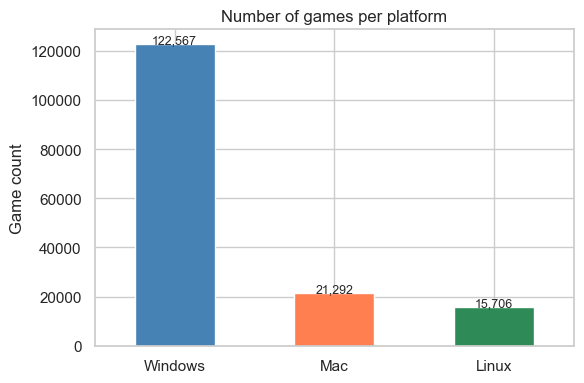

In [16]:
# Platform columns: these are boolean True/False
# Pandas may have loaded them as strings — we fix that first
for col in ['Windows', 'Mac', 'Linux']:
    # Convert string 'True'/'False' → actual boolean if needed
    if df_raw[col].dtype == object:
        df_raw[col] = df_raw[col].map({'True': True, 'False': False})

platform_counts = pd.Series({
    'Windows': df_raw['Windows'].sum(),
    'Mac': df_raw['Mac'].sum(),
    'Linux': df_raw['Linux'].sum()
})

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
platform_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'seagreen'])
ax.set_title('Number of games per platform')
ax.set_ylabel('Game count')
ax.set_xticklabels(platform_counts.index, rotation=0)

# Add count labels on top of each bar
for i, v in enumerate(platform_counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Step 9 – Save a Quick Summary and Move On

We don't modify the data in this section — we only **read and understand** it.  
All cleaning happens in Section 2 (Preprocessing).

Here's a quick summary of what we found:


In [17]:
# Summary printout — a recap of what we observed
total = len(df_raw)
with_reviews = total - len(df_raw[(df_raw['Positive'] == 0) & (df_raw['Negative'] == 0)])

print('='*55)
print('  SECTION 1 SUMMARY')
print('='*55)
print(f'  Total games in dataset        : {total:>10,}')
print(f'  Games with at least 1 review  : {with_reviews:>10,}')
print(f'  Number of features (columns)  : {df_raw.shape[1]:>10}')
print(f'  Columns with missing values   : {df_raw.isnull().any().sum():>10}')
print(f'  Platforms covered             : Windows, Mac, Linux')
print()
print('  Key tasks ahead (Sections 2–7):')
print('  → Section 2: Clean & preprocess the data')
print('  → Section 3: EDA — charts & distributions')
print('  → Section 4: Build classification model (Good/Bad)')
print('  → Section 5: Build regression model (Peak CCU)')
print('  → Section 6: Discover clusters (market segments)')
print('='*55)

  SECTION 1 SUMMARY
  Total games in dataset        :    122,611
  Games with at least 1 review  :     82,949
  Number of features (columns)  :         39
  Columns with missing values   :         17
  Platforms covered             : Windows, Mac, Linux

  Key tasks ahead (Sections 2–7):
  → Section 2: Clean & preprocess the data
  → Section 3: EDA — charts & distributions
  → Section 4: Build classification model (Good/Bad)
  → Section 5: Build regression model (Peak CCU)
  → Section 6: Discover clusters (market segments)


---
## What this notebook did — plain English summary

1. **Loaded** the raw Steam games CSV file (~122,000 games)
2. **Inspected** the column names and data types
3. **Found missing values** and visualised which columns are worst
4. **Checked summary statistics** for key numeric columns (price, reviews, CCU)
5. **Identified** that ~half the games have zero reviews → need to remove them
6. **Previewed** tricky columns: owner ranges (stored as text ranges) and genres/tags (comma-separated lists)
7. **Checked platform distribution** — most games are Windows-only

**Nothing was changed.** The raw data is untouched.  
All transformations happen in the next notebook: `section2_preprocessing.ipynb`
